In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

Лабораторная работа №1

Написали: Кривенцова Юля [408902] и Латышева Анастасия [408987]

#Точные методы решения СЛАУ



Функция ``forward(L, b)`` реализует прямой ход, ``backward(U, b)`` – обратный.

In [ ]:
def forward(L, b):
    n = L.shape[0]
    y = np.zeros((n, 1))
    for i in range(n):
        y[i] = (b[i] - np.sum(L[i, :i] * y[:i, 0])) / L[i, i]
    return y

def backward(U, b):
    n = U.shape[0]
    x = np.zeros((n, 1))
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - np.sum(U[i, i+1:] * x[i+1:, 0])) / U[i, i]
    return x

##Метод Гаусса

Генерация $A \in M_n(\mathbb{R})$ и $b \in M_{n\times 1}(\mathbb{R})$, где $a_{ij}, b_i \in \textrm{Uniform}[-100, 100]$. В процессе генерации верифицируем невырожденность матрицы.

In [ ]:
def A_generation(n):
    A = np.random.uniform(-100, 100, size=(n, n))
    while (np.linalg.det(A) < 1e-8):
      A = np.random.uniform(-100, 100, size=(n, n))
    return A

def b_generation(n):
    return np.random.uniform(-100, 100, size=(n, 1))

Ввод размерностей $A$

In [ ]:
n = [10, 50]

Функция ``Gauss(A, b)`` реализует метод Гаусса для расширенной матрицы, ``backward(A,b)`` принимает результат работы ``Gauss(A, b)``.



In [ ]:
def Gauss(A, b):
  n, m = A.shape
  assert n==m, 'Не квадратная матрица'
  Ab = np.hstack((A, b))

  for i in range(n):
    idx_max_abs = np.argmax(np.abs(Ab[i:, i])) + i
    Ab[[i, idx_max_abs]] = Ab[[idx_max_abs, i]]
    Ab[i, :] = Ab[i, :] / Ab[i, i]
    for j in range(i+1, n):
      Ab[j, :] -= Ab[j,i] * Ab[i, :]

  A_new = Ab[:, :-1]
  b_new = Ab[:, -1]

  return A_new, b_new

In [ ]:
for size in n:
  print(f"Size of matrix: {size}")
  A = A_generation(size)
  b = b_generation(size)
  A_new, b_new = Gauss(A, b)
  solution = backward(A_new, b_new)
  error = np.linalg.norm(A @ solution - b)
  print(f"l_2 norm of error: {error}")
  print("-----------------------------------------")

Size of matrix: 10
l_2 norm of error: 4.983939424150259e-13
-----------------------------------------
Size of matrix: 50
l_2 norm of error: 7.817597712703946e-12
-----------------------------------------


Найдены нормы разности между $Ax^*$ и $b$, где $x^*$ – найденное решение. Норма, как абсолютная погрешность, имеет порядок менее $10^{-10}$.

## $\textrm{LU}$-факторизация

Генерация $A \in M_{n}(\mathbb{R})$ отличается дополнительной верификацией на невырожденность главных миноров (возможность $\textrm{LU}$-разложения).

In [ ]:
def A_LUgeneration(n):
    A = np.random.uniform(-100, 100, size=(n, n))
    while any(abs(np.linalg.det(A[:i, :i])) < 1e-8 for i in range(1, n + 1)):
      A = np.random.uniform(-100, 100, size=(n, n))
    return A

$A = \textrm{LU}$, где
$$\textrm{L} = \begin{pmatrix}
1 & 0 & \cdots & 0 \\
\ell_{21} & 1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
\ell_{n1} & \ell_{n2} & \cdots & 1
\end{pmatrix}
,\quad
\textrm{U} = \begin{pmatrix}
u_{11} & u_{12} & \cdots & u_{1n} \\
0 & u_{22} & \cdots & u_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & u_{nn}
\end{pmatrix}, \quad u_{ii} \neq 0.$$

Элементы $\textrm{L}$ и $\textrm{U}$ можно найти рекурсивно:
$$\begin{aligned}
u_{ij} &= a_{ij} - \sum_{k=1}^{i-1} \ell_{ik} u_{kj}, \\
\ell_{ji} &= \frac{1}{u_{ii}} \left( a_{ji} - \sum_{k=1}^{i-1} \ell_{jk} u_{ki} \right).
\end{aligned}$$

In [ ]:
n = [10, 50]

Функция ``LU_recursive(A)`` принимает на вход матрицу $A$, для которой возможно $\textrm{LU}$-разложение, выдает $\textrm{L}$ и $\textrm{U}$, которые находятся рекурсивно.

In [ ]:
def LU_recursive(A):
  n = A.shape[0]
  L, U = np.eye(n), np.zeros((n, n))

  for i in range(n):
        U[i, i:] = A[i, i:] - L[i, :i] @ U[:i, i:]
        L[i + 1:, i] = (A[i + 1:, i] - L[i + 1:, :i] @ U[:i, i]) / U[i, i]
  return L, U

In [ ]:
for size in n:
  print(f"Size of matrix: {size}")
  A = A_LUgeneration(size)
  L, U = LU_recursive(A)
  print(f"l_2 norm of error: {np.linalg.norm(A - L @ U)}")
  print("-----------------------------------------")

Size of matrix: 10
l_2 norm of error: 2.9403468196635344e-13
-----------------------------------------
Size of matrix: 50
l_2 norm of error: 1.828943740133959e-10
-----------------------------------------


Порядок нормы разности $A$ и найденного $\textrm{LU}$ менее $10^{-7}$.

## Разложение Холецкого

Функция ``pos_by_sylvester(n)`` пропускает матрицы, удовлетворяющие критерию Сильвестра,``pos_AAT(n)`` использует положительную определенность $AA^\top$ при невырожденности $A$.

In [ ]:
def pos_by_sylvester(n):
    A = np.random.uniform(-100, 100, size=(n, n))
    while any(np.linalg.det(A[:i, :i]) < 1e-8 for i in range(1, n + 1)):
      A = np.random.uniform(-100, 100, size=(n, n))
    return A

def pos_AAT(n):
    A = A_generation(n)
    return A @ A.T

В данном разложени $A=\textrm{LL}^\top$, где
$$\textrm{L} = \begin{pmatrix}
\ell_{11} & 0 & \cdots & 0 \\
\ell_{21} & \ell_{22} & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
\ell_{n1} & \ell_{n2} & \cdots & \ell_{nn}
\end{pmatrix}.$$
Формулы для элементов $\textrm{L}$ получены из равенства элементов матриц: $A=\textrm{LL}^\top \Rightarrow a_{ij} = (\textrm{LL}^\top)_{ij} = \sum\limits_{k=1}^n\ell_{ik}\ell_{jk}.$

$$ \begin{aligned}
a_{11} &= \sum\limits_{k=1}^n\ell_{1k}^2=\ell_{11}^2 &&\Rightarrow& \ell_{11}&=\sqrt{a_{11}},\\
a_{j1} &=\sum\limits_{k=1}^n\ell_{jk}\ell_{1k} = \ell_{j1}\ell_{11} &&\Rightarrow& \ell_{j1} &= \frac{a_{j1}}{\sqrt{a_{11}}}, \quad 1 \leq j \leq n,\\
a_{ii} &= \sum\limits_{k=1}^n\ell_{ik}^2 = \sum\limits_{k=1}^{i-1}\ell_{ik}^2 + \ell_{ii}^2 &&\Rightarrow& \ell_{ii} &= \sqrt{a_{ii} - \displaystyle\sum_{k=1}^{i-1} \ell_{ik}^2}, \quad 2 \leq i \leq n,\\
a_{ij} &= \sum\limits_{k=1}^n\ell_{ik}\ell_{jk} = \sum\limits_{k=1}^i\ell_{ik}\ell_{jk} = \sum\limits_{k=1}^{i-1}\ell_{ik}\ell_{jk}+\ell_{ii}\ell_{ji} &&\Rightarrow& \ell_{ji} &= \dfrac{1}{\ell_{ii}}\left(a_{ji} - \sum_{k=1}^{i-1} \ell_{jk}\ell_{ik}\right), \quad i < j.
\end{aligned}$$
Эти формулы имеют смысл, потому что разложение Холецкого применимо к любой положительно определенной матрице.

Функция ``cholesky_decomposition(A)`` принимает $A$ и выдает $\textrm{L}$, найденное по записанным выше формулам.

In [ ]:
def cholesky_decomposition(A):
  spectrum = np.linalg.eigvalsh(A)
  assert all(lambd > 0 for lambd in spectrum), 'Не положительно определенная матрица =)'
  n = A.shape[0]
  L = np.zeros((n,n))
  L[:, 0] = A[:, 0] / np.sqrt(A[0, 0])
  for i in range(1, n):
      L[i, i] = np.sqrt(A[i, i] - L[i, :i] @ L[i, :i].T)
      L[i + 1:, i] = 1 / L[i, i] * (A[i + 1:, i] - L[i + 1:, :i] @ L[i, :i])

  return L

In [ ]:
n = [10, 50]

In [ ]:
for size in n:
  print(f"Size of matrix: {size}")
  A = pos_AAT(size)
  L = cholesky_decomposition(A)
  print(f"l_2 norm of error: {np.linalg.norm(A - L @ L.T)}")
  print("-----------------------------------------")

Size of matrix: 10
l_2 norm of error: 1.6553834217556146e-11
-----------------------------------------
Size of matrix: 50
l_2 norm of error: 2.0840608035529637e-10
-----------------------------------------


Порядок нормы разности $(A-\textrm{LL}^\top)$ менее $10^{-8}$.

## Чувствительность и число обусловленности (метод Гаусса, $\textrm{LU}$-факторизация, разложение Холецкого)

Далее потребуется находить относительные ошибки, поэтому вместо столбца $b$ будет генерироваться $x^*$, $b$ получается из $Ax^*=b.$ Так, $x^*$ – реальное решение.

### Матрица Гильберта

Матрица Гильберта $H_{ij} = 1/(i+j-1)$ симметрична и положительно определена. Матрица Гильберта размерности 5: $$H_5 =
\begin{bmatrix}
1 & \tfrac12 & \tfrac13 & \tfrac14 & \tfrac15\\
\tfrac12 & \tfrac13 & \tfrac14 & \tfrac15 & \tfrac16\\
\tfrac13 & \tfrac14 & \tfrac15 & \tfrac16 & \tfrac17\\
\tfrac14 & \tfrac15 & \tfrac16 & \tfrac17 & \tfrac18\\
\tfrac15 & \tfrac16 & \tfrac17 & \tfrac18 & \tfrac19
\end{bmatrix}$$

In [ ]:
from scipy.linalg import hilbert

def generate_real_solution(n, limit = 100):
  return np.random.uniform(-limit, limit, size=(n, 1))

In [ ]:
n = [5, 7, 9, 12]

Поиск и вывод в таблице относительных ошибок и невязок для методов Гаусса, $\textrm{LU}$-расложения и разложения Холецкого для матриц Гильберта различных размерностей.  ``lab1_part1_number4(n, A_func)`` принимает на вход массив натуральных чисел ``n`` (размерности матриц) и функцию ``A_func``, выдающую матрицу заданной размерности. На выходе ``lab1_part1_number4(n, A_func)`` формирует таблицу с относительными ошибками и невязками для трёх методов решения и числами обусловленности и возвращает массивы с данными для построения графика $\frac{\|x - x^*\|}{\|x^*\|}$ от $\nu(A)$. В данном случае в качестве ``A_func`` используется функция ``hilbert``.

In [ ]:
def fmt(x):
    return f"{x:.2e}"

def lab1_part1_number4(n, A_func):
    print(f"{'n':>3} | {'cond(A)':>10} | {'gauss rel':>13} | {'gauss resid':>12} | "
          f"{'LU rel':>12} | {'LU resid':>12} | {'Chol rel':>13} | {'Chol resid':>12}")
    print("-" * 109)

    cond_vals = []
    err_gauss = []
    err_lu = []
    err_chol = []

    # relative error and residual

    for size in n:
        x_real = generate_real_solution(size)
        A = np.array(A_func(size), dtype=float)
        b = A @ x_real

        # ----------------- Gauss -----------------
        try:
            A_new, b_new = Gauss(A, b)
            x_gauss = backward(A_new, b_new)
            rel_err_gauss = np.linalg.norm(x_gauss - x_real) / np.linalg.norm(x_real)
            resid_gauss = np.linalg.norm(A @ x_gauss - b)
        except Exception:
            rel_err_gauss = np.nan
            resid_gauss = np.nan

        # ----------------- LU -----------------
        try:
            L, U = LU_recursive(A)
            y_lu = forward(L, b)
            x_lu = backward(U, y_lu)
            rel_err_lu = np.linalg.norm(x_lu - x_real) / np.linalg.norm(x_real)
            resid_lu   = np.linalg.norm(A @ x_lu - b)
        except Exception:
            rel_err_lu = np.nan
            resid_lu = np.nan

        # ----------------- Cholesky -----------------
        try:
            L_ch = cholesky_decomposition(A)
            y_ch = forward(L_ch, b)
            x_ch = backward(L_ch.T, y_ch)
            rel_err_ch = np.linalg.norm(x_ch - x_real) / np.linalg.norm(x_real)
            resid_ch   = np.linalg.norm(A @ x_ch - b)
        except Exception:
            rel_err_ch = np.nan
            resid_ch = np.nan

        # ----------------- Cond numbers -----------------
        cond_vals.append(np.linalg.cond(A, 2))
        err_gauss.append(rel_err_gauss)
        err_lu.append(rel_err_lu)
        err_chol.append(rel_err_ch)

        print(f"{size:>3d} | {fmt(np.linalg.cond(A)):>10} | "
              f"{fmt(rel_err_gauss):>13} | {fmt(resid_gauss):>12} | "
              f"{fmt(rel_err_lu):>12} | {fmt(resid_lu):>12} | "
              f"{fmt(rel_err_ch):>13} | {fmt(resid_ch):>12}")

    cond_vals = np.array(cond_vals)
    err_gauss = np.array(err_gauss)
    err_lu    = np.array(err_lu)
    err_chol  = np.array(err_chol)

    return cond_vals, err_gauss, err_lu, err_chol


In [ ]:
cond_vals, err_gauss, err_lu, err_chol = lab1_part1_number4(n, hilbert)

  n |    cond(A) |     gauss rel |  gauss resid |       LU rel |     LU resid |      Chol rel |   Chol resid
-------------------------------------------------------------------------------------------------------------
  5 |   4.77e+05 |      2.74e-12 |     9.57e-15 |     2.36e-12 |     1.64e-14 |      6.84e-14 |     5.33e-15
  7 |   4.75e+08 |      2.24e-09 |     9.23e-15 |     2.69e-09 |     5.89e-15 |      2.66e-09 |     7.32e-15
  9 |   4.93e+11 |      2.97e-08 |     4.46e-15 |     1.48e-07 |     8.86e-15 |      5.18e-06 |     9.29e-15
 12 |   1.75e+16 |      4.16e-02 |     1.42e-14 |     1.85e-01 |     1.51e-14 |      6.78e-02 |     2.73e-14


Почему не показано разложение Холецкого для $H_n^2$:

In [ ]:
error_n = []
for size in n:
  spectrum = np.linalg.eigvalsh(hilbert(size) @ hilbert(size))
  if any(lambd < 0 for lambd in spectrum):
    error_n.append(size)

print(error_n) #при n=12 у H^2 не положительный спектр

[12]


$H_n$ и $H_n^2$ положительно определенные матрицы, значит, к ним применимо разложение Холецкого. Численные итоги решения СЛАУ при $H_n$ приведены в таблице выше. При $n=12$ (из числа рассматриваемых по условию размерностей) $H_n^2$ имеет отрицательные числа в спектре (практически! ошибки округления): разложение Холецкого некорректно.

Спектр $H_{12}^2$ в точки зрения машинных вычислений:

In [ ]:
H_12 = hilbert(12)
print(np.linalg.eigvalsh(H_12 @ H_12))

[-1.53134011e-17 -1.16459220e-17 -6.40798115e-19  3.84642889e-17
  1.42867196e-16  1.66680524e-13  1.24620518e-10  5.43305234e-08
  1.38556084e-05  2.00153774e-03  1.44609263e-01  3.22336083e+00]


При $n=9$ вознимают отрицательные числа под корнем в формулах для разложения Холецкого.

In [ ]:
L_ch_9 = cholesky_decomposition(hilbert(9) @ hilbert(9))

/tmp/ipython-input-741370864.py:8: RuntimeWarning: invalid value encountered in sqrt
  L[i, i] = np.sqrt(A[i, i] - L[i, :i] @ L[i, :i].T)


График зависимости $\frac{\|x - x^*\|}{\|x^*\|}$ от $\nu(A)$ для рассмотренных методов:

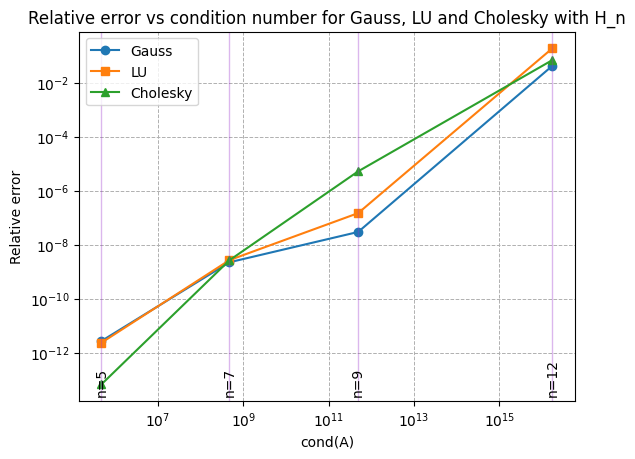

In [ ]:
plt.loglog(cond_vals, err_gauss, 'o-', label='Gauss')
plt.loglog(cond_vals, err_lu, 's-', label='LU')
plt.loglog(cond_vals, err_chol, '^-', label='Cholesky')

for x, ni in zip(cond_vals, n):
    plt.axvline(x, color='darkorchid', linestyle='-', linewidth=1, alpha=0.35)
    plt.text(x, plt.ylim()[0]*1.5, f"n={ni}", rotation=90,
             va='bottom', ha='center', fontsize=10)

plt.xlabel(r'cond(A)')
plt.ylabel('Relative error')
plt.title('Relative error vs condition number for Gauss, LU and Cholesky with H_n')
plt.grid(True, which='both', ls='--', lw=0.7)
plt.legend()
plt.show()

Матрица Гильберта, очевидно, пример плохо обусловленной матрицы $(\nu(A)\gg1)$. Из графика: ошибка возрастает пропорционально обусловленности и значения ошибок для разных методов относительно близки близки. Нельзя выделить конкретный метод.

*P.S. Про эквивалентность $\textrm{LU}$-разложения и разложения Холецкого: $A\in \text{Sym}_n(\mathbb{R}) \Rightarrow A = \textrm{LU}=(\textrm {LU})^\top = \textrm{U}^\top\textrm{L}^\top \Rightarrow A = \textrm{L}(\textrm{L}^{-1}\textrm{U}^\top)\textrm{L}^\top = \left(\textrm{L}(\textrm{L}^{-1}\textrm{U}^\top)^{1/2}\right)\left(\textrm{L}(\textrm{L}^{-1}\textrm{U}^\top)^{1/2}\right)^\top.$*

### Диагонально преобладающая матрица

``generate_diagonally_dominant_matrix(n)`` генерирует диагонально преобладающую матрицу:
1. $A: a_{ij} \in \textrm{Uniform}[-50,50]$,
2. $a_{ii} = \xi_i\left(\sum\limits_{k=1}^n |a_{ik}| + b_i\right)$, где $b_i \in \textrm{Uniform}[1, 10]$, $\xi_i \in \textrm{Uniform}\{-1, 1\}.$

In [ ]:
def generate_diagonally_dominant_matrix(n):
    A = np.random.uniform(-50, 50, size=(n, n))
    for i in range(n):
        A[i, i] = np.random.choice([-1, 1]) * (np.sum(np.abs(A[i, :])) + np.random.uniform(1, 10))
    return A

In [ ]:
n = [5, 7, 9, 12, 50]

Таблица с ошибками:

In [ ]:
cond_vals, err_gauss, err_lu, err_chol = lab1_part1_number4(n, generate_diagonally_dominant_matrix)

  n |    cond(A) |     gauss rel |  gauss resid |       LU rel |     LU resid |      Chol rel |   Chol resid
-------------------------------------------------------------------------------------------------------------
  5 |   2.56e+00 |      1.15e-16 |     2.03e-12 |     1.24e-16 |     1.82e-12 |           nan |          nan
  7 |   2.76e+00 |      1.62e-16 |     2.91e-12 |     1.40e-16 |     4.17e-12 |           nan |          nan
  9 |   2.65e+00 |      3.23e-16 |     8.45e-12 |     2.76e-16 |     5.91e-12 |           nan |          nan
 12 |   2.31e+00 |      1.25e-16 |     9.31e-12 |     9.66e-17 |     6.67e-12 |           nan |          nan
 50 |   1.73e+00 |      3.66e-16 |     1.89e-10 |     2.00e-16 |     8.87e-11 |           nan |          nan


Функция ``generate_diagonally_dominant_matrix(n)`` "почти наверное" не выдаст положительно определенную матрицу, поэтому в столбцах ``Chol`` закономерно имеем ``nan``.

Remark: при генерации нет никакой верификации!

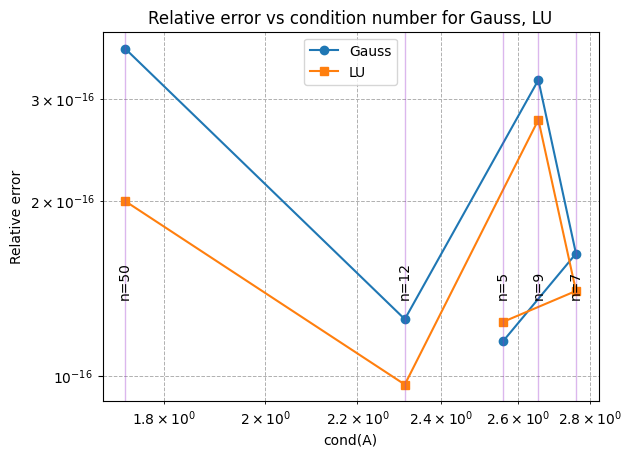

In [ ]:
plt.loglog(cond_vals, err_gauss, 'o-', label='Gauss')
plt.loglog(cond_vals, err_lu, 's-', label='LU')

for x, ni in zip(cond_vals, n):
    plt.axvline(x, color='darkorchid', linestyle='-', linewidth=1, alpha=0.35)
    plt.text(x, plt.ylim()[0]*1.5, f"n={ni}", rotation=90,
             va='bottom', ha='center', fontsize=10)

plt.xlabel(r'cond(A)')
plt.ylabel('Relative error')
plt.title('Relative error vs condition number for Gauss, LU')
plt.grid(True, which='both', ls='--', lw=0.7)
plt.legend()
plt.show()

Матрицы с преобладающей диагональю хорошо обусловлены, нет явной зависимости $\nu(A)$ от $n$.

### Положительно определенная: $A = B^\top B + \alpha E$

В данной ситуации нет требований к матрице $B$ (даже к размерности). Будем генерировать квадратную матрицу с элементами из $\text{Uniform}\left[-\frac{100}{\sqrt{n}}, \frac{100}{\sqrt{n}}\right]$.

In [ ]:
n = [5, 12, 50, 100, 300]

In [ ]:
def generate_spd_matrix_from_B(n, limit=100, alpha = 0.05):
  B = np.random.uniform(-limit, limit, size=(n, n)) / np.sqrt(n)
  A = B.T @ B + alpha * np.eye(n)
  return A

In [ ]:
cond_vals, err_gauss, err_lu, err_chol = lab1_part1_number4(n, generate_spd_matrix_from_B)

  n |    cond(A) |     gauss rel |  gauss resid |       LU rel |     LU resid |      Chol rel |   Chol resid
-------------------------------------------------------------------------------------------------------------
  5 |   2.13e+03 |      3.74e-14 |     4.56e-11 |     4.25e-14 |     3.01e-11 |      1.13e-13 |     1.57e-10
 12 |   6.53e+02 |      7.73e-15 |     1.96e-10 |     7.01e-15 |     2.76e-10 |      4.31e-15 |     1.93e-10
 50 |   2.81e+03 |      6.15e-14 |     5.15e-10 |     4.71e-14 |     3.68e-10 |      2.92e-14 |     3.76e-10
100 |   2.46e+05 |      1.74e-12 |     1.25e-09 |     3.67e-12 |     7.13e-10 |      4.39e-12 |     8.28e-10
300 |   1.61e+05 |      3.80e-12 |     3.03e-09 |     3.32e-12 |     1.74e-09 |      2.64e-12 |     1.88e-09


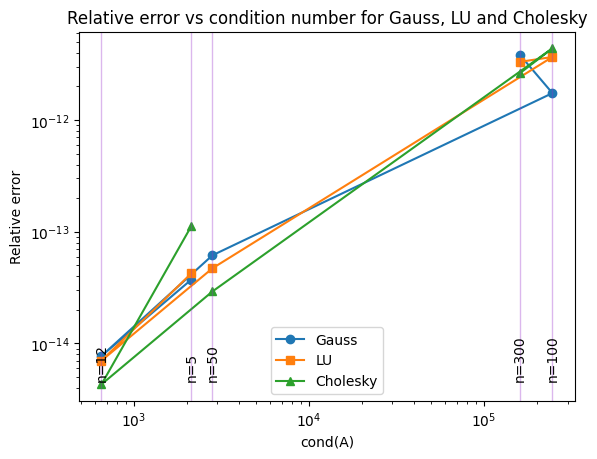

In [ ]:
plt.loglog(cond_vals, err_gauss, 'o-', label='Gauss')
plt.loglog(cond_vals, err_lu, 's-', label='LU')
plt.loglog(cond_vals, err_chol, '^-', label='Cholesky')

for x, ni in zip(cond_vals, n):
    plt.axvline(x, color='darkorchid', linestyle='-', linewidth=1, alpha=0.35)
    plt.text(x, plt.ylim()[0]*1.5, f"n={ni}", rotation=90,
             va='bottom', ha='center', fontsize=10)

plt.xlabel(r'cond(A)')
plt.ylabel('Relative error')
plt.title('Relative error vs condition number for Gauss, LU and Cholesky')
plt.grid(True, which='both', ls='', lw=0.7)
plt.legend()
plt.show()

Матрицы, построенные как $A=B^\top B+\alpha E$, нельзя назвать хорошо обусловленными при малых значениях $n$, однако можно назвать плохо обусловленными при больших значениях $n$. Нет явной зависимости $\nu(A)$ от $n$.

#Итерационные методы решения СЛАУ

## Релизация метода Якоби

Пусть $Ax^*=b$, тогда для метода Якоби:

$$x^{(k+1)} = -D^{-1}(L+U)x^{(k)}+D^{-1}b,$$
где $A = L + D + U$.

Функция ``jacobi(A, b, x_0 = None, max_iter = 4_000)`` реализует метод Якоби для решения системы $Ax=b$. Принимает матрицу $A$, столбец $b$, опционально начальное приближение $x_0$ (по умолчанию нулевой) и ``max_iter``, определяющий максимальное число итераций. Возвращает массив приближений $x^{(k)}$ и невязок $\|Ax^{(k)}-b\|_2$.

In [ ]:
max_resid = 1e-8 #требование лабораторной

In [ ]:
def jacobi(A, b, x_0 = None, max_iter = 4_000): #хотим на выходе найденное решение, количество итераций и динамику невязок (для сравнения скороси сходимости?)
  n = A.shape[0]

  D = np.diag(np.diag(A))
  D_inv = np.diag(1 / np.diag(A))
  B = -D_inv @ (A - D)
  c = D_inv @ b

  x_values = []
  iter = 0
  resid_dynamics = []

  if x_0 is None:
    x_0 = np.zeros(n)

  x = np.array(x_0, float).reshape(-1, 1)

  while np.linalg.norm(A @ x - b) > max_resid and iter < max_iter:
    x = B @ x + c
    x_values.append(x)
    iter += 1
    resid = np.linalg.norm(A @ x - b)
    resid_dynamics.append(resid)

  return x_values, resid_dynamics

 ## Реализация метода Гаусса-Зейделя

Пусть $Ax^*=b$, тогда для метода Гаусса-Зейделя:
$$x^{(k+1)} = -(D + L)^{-1} U x^{(k)} + (D + L)^{-1} b,$$
где $A = L + D + U.$

Функция ``gauss_seidel(A, b, x_0=None, max_iter=4000)`` реализует метод Гаусса–Зейделя для решения системы $A x = b$. Принимает матрицу $A$, столбец $b$, опционально начальное приближение $x^{(0)}$ (по умолчанию нулевой вектор) и ``max_iter``, определяющий максимальное число итераций. Возвращает массив приближений $x^{(k)}$ и невязок $\|A x^{(k)} - b\|_2$.

In [ ]:
def gauss_seidel(A, b, x_0 = None, max_iter=4_000):
  n = A.shape[0]
  D_plus_L = np.tril(A)
  U = np.triu(A, k=1)

  x_values = []
  iter = 0
  resid_dynamics = []

  if x_0 is None:
    x_0 = np.zeros(n)

  x = np.array(x_0, float).reshape(-1, 1)

  while np.linalg.norm(A @ x - b) > max_resid and iter < max_iter:
    c = b - (U @ x)
    x = forward(D_plus_L, c)
    x_values.append(x)
    iter += 1
    resid = np.linalg.norm(A @ x - b)
    resid_dynamics.append(resid)

  return x_values, resid_dynamics

## Методы Якоби и Гаусса-Зейделя для диагонально преобладающих матриц

### Сравнение сходимости методов Якоби и Гаусса–Зейделя

Имеем знание, что методы Якоби и Гаусса-Зейделя сходятся для диагонально преобладающих матриц. Диагонально преобладающие матрицы хорошо обусловлены, поэтому здесь резонен критерий невязки.

In [ ]:
n = np.arange(5, 150 + 1, 10)

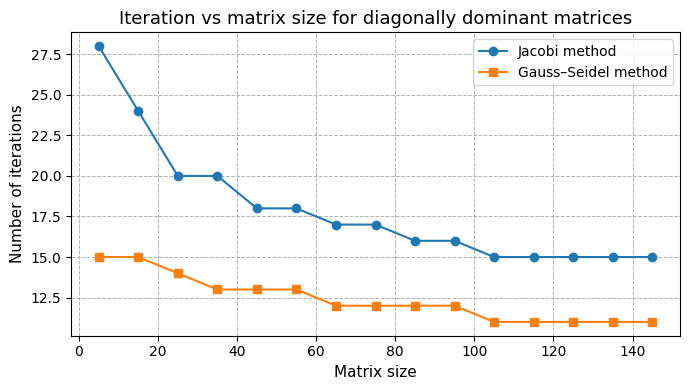

In [ ]:
jacobi_iters = []
gauss_seidel_iters = []

for size in n:
  A = generate_diagonally_dominant_matrix(size)

  x_real = generate_real_solution(size)
  b = A @ x_real

  jacobi_resid_dynamics = jacobi(A, b, x_0 = None)[1]
  gauss_seidel_resid_dynamics = gauss_seidel(A, b, x_0 = None)[1]

  jacobi_iters.append(len(jacobi_resid_dynamics))
  gauss_seidel_iters.append(len(gauss_seidel_resid_dynamics))

plt.figure(figsize=(7, 4))
plt.plot(n, jacobi_iters, 'o-', label='Jacobi method')
plt.plot(n, gauss_seidel_iters, 's-', label='Gauss–Seidel method')

plt.xlabel('Matrix size', fontsize=11)
plt.ylabel('Number of iterations', fontsize=11)
plt.title('Iteration vs matrix size for diagonally dominant matrices', fontsize=13)
plt.grid(True, linestyle='--', linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()

При увеличении размерности матрицы оба метода сходятся быстрее. Метод Гаусса-Зейделя за меньшее число итераций *находит* решение (удовлетворяет критерию).

### Ослабление диагонального преобладания, влияние на сходимость

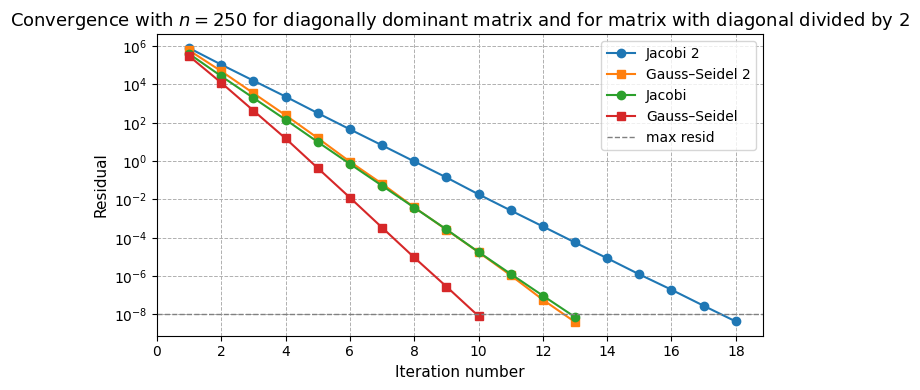

In [ ]:
size = 250

A = generate_diagonally_dominant_matrix(size)
A_diag_divide2 = A - np.diag(np.diag(A) / 2)
x_real = generate_real_solution(size)
b = A @ x_real

jacobi_resid_dynamics = jacobi(A, b, x_0 = None)[1]
gauss_seidel_resid_dynamics = gauss_seidel(A, b, x_0 = None)[1]
jacobi_resid_dynamics_2 = jacobi(A_diag_divide2, b, x_0 = None)[1]
gauss_seidel_resid_dynamics_2 = gauss_seidel(A_diag_divide2, b, x_0 = None)[1]

k_j_2, k_j = np.arange(1, len(jacobi_resid_dynamics_2) + 1), np.arange(1, len(jacobi_resid_dynamics) + 1)
k_gs_2, k_gs = np.arange(1, len(gauss_seidel_resid_dynamics_2) + 1), np.arange(1, len(gauss_seidel_resid_dynamics) + 1)

plt.figure(figsize=(7, 4))
plt.semilogy(k_j_2, jacobi_resid_dynamics_2, 'o-', label='Jacobi 2',  markersize=6)
plt.semilogy(k_gs_2, gauss_seidel_resid_dynamics_2, 's-', label='Gauss–Seidel 2',  markersize=6)
plt.semilogy(k_j, jacobi_resid_dynamics, 'o-', label='Jacobi',  markersize=6)
plt.semilogy(k_gs, gauss_seidel_resid_dynamics, 's-', label='Gauss–Seidel',  markersize=6)

plt.axhline(max_resid, linestyle='--', linewidth=1, color='gray', label='max resid')

plt.xlabel('Iteration number', fontsize=11)
plt.ylabel('Residual', fontsize=11)
plt.title(f'Convergence with $n = {size}$ for diagonally dominant matrix and for matrix with diagonal divided by 2', fontsize=13)
plt.grid(True, which='both', linestyle='--', linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.xticks(np.arange(0, max(max(arr) for arr in [k_gs_2, k_gs, k_j, k_j_2]) + 2, 2))
plt.show()

Ослабление диагонали, очевидно, не влияет на характер сходимости, так как рассмотренные методы в рамках решения СЛАУ $-$ методы простой итерации $-$ из теоретических соображений, если сходятся, то обязательно линейно, что также *видно* на графике. Ослабление диагонали повлияло на количество итераций: их число увеличилилось.

### Сходимость при положительно определенной матрице $A=B^\top B + \alpha E \in M_{500}(\mathbb{R})$

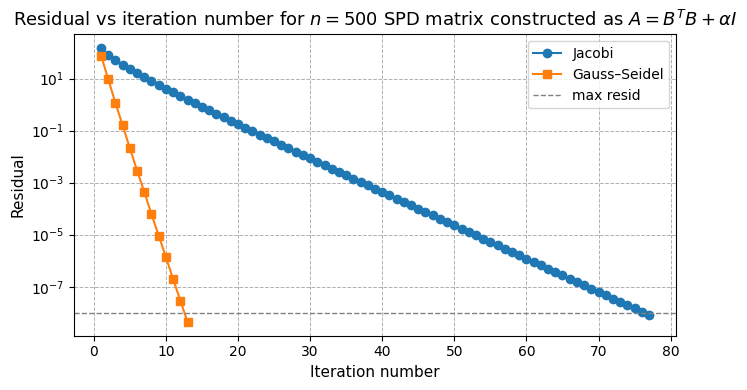

In [ ]:
size = 500
A = generate_spd_matrix_from_B(size, limit=5, alpha = 25)
x_real = generate_real_solution(size, limit = 1)
b = A @ x_real

jacobi_resid_dynamics = jacobi(A, b, x_0 = None)[1]
gauss_seidel_resid_dynamics = gauss_seidel(A, b, x_0 = None)[1]

plt.figure(figsize=(7, 4))
plt.semilogy(np.arange(1, len(jacobi_resid_dynamics) + 1), jacobi_resid_dynamics, 'o-', label='Jacobi',  markersize=6)
plt.semilogy(np.arange(1, len(gauss_seidel_resid_dynamics) + 1), gauss_seidel_resid_dynamics, 's-', label='Gauss–Seidel',  markersize=6)

plt.axhline(max_resid, linestyle='--', linewidth=1, color='gray', label='max resid')

plt.xlabel('Iteration number', fontsize=11)
plt.ylabel('Residual', fontsize=11)
plt.title(r'Residual vs iteration number for $n = 500$ SPD matrix constructed as $A = B^T B + \alpha I$', fontsize=13)
plt.grid(True, which='both', linestyle='--', linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Iteration ratio = ", len(jacobi_resid_dynamics) / len(gauss_seidel_resid_dynamics)) #во сколько раз Гаусс быстрее

Iteration ratio =  5.923076923076923


Линейная сходимость. Метод Гаусса-Зейделя в $\approx5$ раз быстрее метода Якоби для данных параметров матрицы.

### Влияние начального приближения $x^{(0)}$

Для матриц с преобладающей диагональю исследуем влияние начального приближения:
1. ``x0_zero`` $-$ нулевой вектор,
2. ``x0_random_from_sphere`` $-$ вектор из равномерного распределения на единичной сфере в $\mathbb{R}^n$ (получается из нормировки векторов из стандартного нормального распределения),
3. ``x0_near_real`` $-$ близкий к $x^*$, выполняется условие гомоскедантичности.

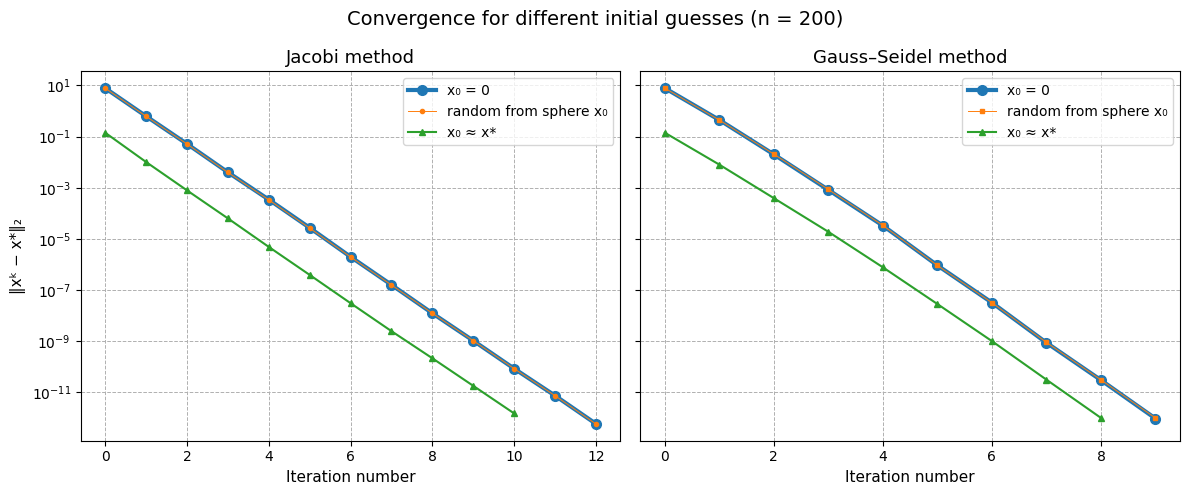

In [ ]:
n = 200

A = generate_diagonally_dominant_matrix(n)
x_real = generate_real_solution(n, limit=1)
b = A @ x_real

x0_zero = np.zeros((n, 1))
x0_random_from_sphere = np.random.randn(n, 1)
x0_random_from_sphere /= np.linalg.norm(x0_random_from_sphere)
x0_near_real = x_real + 0.01 * np.random.randn(n, 1)

jacobi_zero_x = jacobi(A, b, x_0=x0_zero)[0]
jacobi_rand_x = jacobi(A, b, x_0=x0_random_from_sphere)[0]
jacobi_near_x = jacobi(A, b, x_0=x0_near_real)[0]

gs_zero_x = gauss_seidel(A, b, x_0=x0_zero)[0]
gs_rand_x = gauss_seidel(A, b, x_0=x0_random_from_sphere)[0]
gs_near_x = gauss_seidel(A, b, x_0=x0_near_real)[0]

def error_dynamics(x0, x_real, x_values):
    errors = [np.linalg.norm(x - x_real) for x in x_values]
    errors.insert(0, np.linalg.norm(x0 - x_real))
    return np.array(errors)

jacobi_zero_err = error_dynamics(x0_zero, x_real, jacobi_zero_x)
jacobi_rand_err = error_dynamics(x0_random_from_sphere, x_real, jacobi_rand_x)
jacobi_near_err = error_dynamics(x0_near_real, x_real, jacobi_near_x)

gs_zero_err = error_dynamics(x0_zero, x_real, gs_zero_x)
gs_rand_err = error_dynamics(x0_random_from_sphere, x_real, gs_rand_x)
gs_near_err = error_dynamics(x0_near_real, x_real, gs_near_x)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].semilogy(jacobi_zero_err, 'o-', label='x₀ = 0', linewidth=3, markersize=7)
axes[0].semilogy(jacobi_rand_err, 'o-', label='random from sphere x₀', linewidth=0.7, markersize=3)
axes[0].semilogy(jacobi_near_err, '^-', label='x₀ ≈ x*', markersize=5)
axes[0].set_title('Jacobi method', fontsize=13)
axes[0].set_xlabel('Iteration number', fontsize=11)
axes[0].set_ylabel('‖xᵏ − x*‖₂', fontsize=11)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.7)
axes[0].legend()

axes[1].semilogy(gs_zero_err, 'o-', label='x₀ = 0', linewidth=3, markersize=7)
axes[1].semilogy(gs_rand_err, 's-', label='random from sphere x₀', linewidth=0.7, markersize=3)
axes[1].semilogy(gs_near_err, '^-', label='x₀ ≈ x*', markersize=5)
axes[1].set_title('Gauss–Seidel method', fontsize=13)
axes[1].set_xlabel('Iteration number', fontsize=11)
axes[1].grid(True, which='both', linestyle='--', linewidth=0.7)
axes[1].legend()

fig.suptitle(f'Convergence for different initial guesses (n = {n})', fontsize=14) #при разных нач прибл
plt.tight_layout()
plt.show() #на самом деле итерации тут со сдвигом -1, типа 0, 1, 2, 3, ... ! исправлено, добавлен нулевой "ход"


In [ ]:
print("‖x0_zero − x0_random_from_sphere‖ / ‖x_real‖ =", np.linalg.norm(x0_zero - x0_random_from_sphere) / np.linalg.norm(x_real))
print("‖x0_zero − x_real‖ =", np.linalg.norm(x0_zero - x_real))
print("‖x0_random_from_sphere − x_real‖ =", np.linalg.norm(x0_random_from_sphere - x_real))


‖x0_zero − x0_random_from_sphere‖ / ‖x_real‖ = 0.12733867280588698
‖x0_zero − x_real‖ = 7.853073838176277
‖x0_random_from_sphere − x_real‖ = 7.840152641733833


Наклон прямой, характеризующей линейную сходимость, определяется спектром оператора $B$, поэтому следует ожидать, что прямые в рамках одного графика будут отличаться линейным сдвигом, характеризующим начальную невязку. Видим, что случаи $x^{(0)}=0$ и $\|x^{(0)} \|= 1$ *совпадают*, это аргументируется небольшой относительной разностью $\frac{\|x_1^{(0)} - x_2^{(0)}\|}{\|x^*\|}$.

# Нелинейные уравнения и системы

## Метод Ньютона, метод секущих и метод одной касательной в одномерном случае

### Метод Ньютона

Итеративный процесс для метода Ньютона:
$$x_{k+1} = x_k -\frac{f(x_k)}{f'(x_k)}.$$

Функция ``newton(f, df, x_0, epsilon = 1e-10, max_iter = 4000)`` реализует метод Ньютона для нахождения корней дифференцируемой функции $f(x)$. Принимает функцию ``f``, функцию ее производной ``df``, начальное приближение ``x_0``. Возвращает массив приближений $x_k$ (включая нулевое).

In [ ]:
def newton(f, df, x_0, epsilon = 1e-10, max_iter = 4000):
  x_values = [x_0]
  x = float(x_0)
  iter = 0

  while abs(f(x))>= epsilon and iter < max_iter:
    x -= (f(x) / df(x))
    x_values.append(x)
    iter+=1

  return x_values

### Метод секущих

Итеративный процесс:
$$
x_{k+1} = x_k - f(x_k)\,\frac{x_k - x_{k-1}}{f(x_k) - f(x_{k-1})}.
$$

Функция ``secant(f, x_0, x_1, epsilon = 1e-10, max_iter = 4000)`` реализует метод секущих для нахождения корней функции $f(x)$.
Принимает функцию ``f`` и два начальных приближения ``x_0`` и ``x_1``.
Возвращает массив приближений $x_k$ (включая нулевое).

In [ ]:
def secant(f, x_0, x_1, epsilon = 1e-10, max_iter = 4000):
  x_values = [x_0, x_1]
  x = float(x_1)
  iter = 0

  while abs(f(x))>= epsilon and iter < max_iter:
    x -= (f(x) * (x-x_values[-2])/(f(x)-f(x_values[-2])))
    x_values.append(x)
    iter+=1

  return x_values

### Метод одной касательной

Итерационный процесс:
$$
x_{k+1} = x_k - \frac{f(x_k)}{f'(x_0)}.
$$

Функция ``modified_newton(f, df, x_0, epsilon = 1e-10, max_iter = 4000)`` реализует метод одной касательной для нахождения корней функции $f(x)$.
Принимает функцию ``f``, функцию ее производной ``df``, начальное приближение ``x_0``.
Возвращает массив приближений $x_k$ (включая нулевое).

In [ ]:
def modified_newton(f, df, x_0, epsilon = 1e-10, max_iter = 4000):
  x_values = [x_0]
  x = float(x_0)
  iter = 0

  while abs(f(x))>= epsilon and iter < max_iter:
    x -= (f(x) / df(x_0))
    x_values.append(x)
    iter+=1

  return x_values

### Эксперименты

Требуется провести численные эксперименты по нахождению корней функций:
$$
f_1(x)=x^2-2, \quad
f_2(x)=\cos x - x, \quad
f_3(x)=e^{-x} - x.
$$

Аналитически:
 $$x_1^* = \pm \sqrt{2} \approx \pm 1.414, \quad x_2^* = x_D \approx 0.739, $$
 где $x_D$ $-$ число Дотти $-$ вещественная неподвижная точка косинуса.

 $f_3 - $ строго убывающая: $f_3(0) = 1 > 0, f_3(1) < 0 \Rightarrow x_3^* \in (0, 1)$.

Далее используется для выбора $x_0$ (и $x_1$).


In [ ]:
x_dottie = 0.73908513321516064165

Зададим исследуемые функции и их производные:

In [ ]:
f1 = lambda x: x**2 - 2
f2 = lambda x: np.cos(x) - x
f3 = lambda x: np.exp(-x) - x

df1 = lambda x: 2*x
df2 = lambda x: -np.sin(x) - 1
df3 = lambda x: -np.exp(-x) - 1

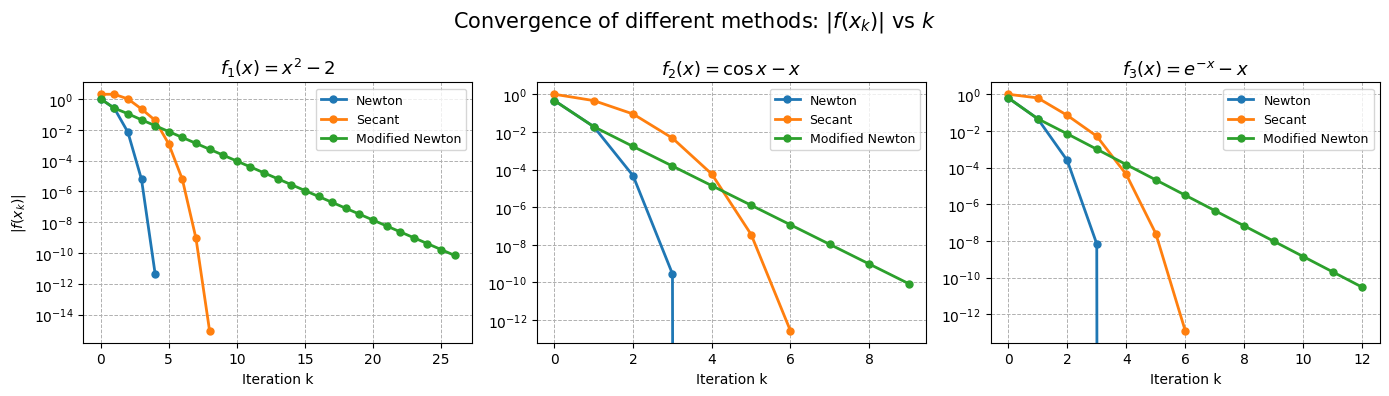

In [ ]:
xs1_n  = newton(f1, df1, 1)
xs1_s  = secant(f1, 0, 2)
xs1_m  = modified_newton(f1, df1, 1)

xs2_n  = newton(f2, df2, 1)
xs2_s  = secant(f2, 0, 1)
xs2_m  = modified_newton(f2, df2, 1)

xs3_n  = newton(f3, df3, 1)
xs3_s  = secant(f3, 0, 1)
xs3_m  = modified_newton(f3, df3, 1)

functions = [
    (f1, df1, r"$f_1(x)=x^2-2$"),
    (f2, df2, r"$f_2(x)=\cos x-x$"),
    (f3, df3, r"$f_3(x)=e^{-x}-x$")
]
methods = ['Newton', 'Secant', 'Modified Newton']
results = [
    (xs1_n, xs1_s, xs1_m),
    (xs2_n, xs2_s, xs2_m),
    (xs3_n, xs3_s, xs3_m)
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i in range(3):
    ax = axes[i]
    f = functions[i][0]
    xsets = results[i]

    for method, xs in zip(methods, xsets):
        k = np.arange(len(xs))
        y = np.abs(f(np.array(xs)))
        ax.semilogy(k, y, 'o-', linewidth=2, markersize=5, label=method)

    ax.set_title(functions[i][2], fontsize=13)
    ax.set_xlabel('Iteration k')
    if i == 0:
        ax.set_ylabel(r'$|f(x_k)|$')
    ax.grid(True, which='both', ls='--', lw=0.7)
    ax.legend(fontsize=9)

fig.suptitle(r'Convergence of different methods: $|f(x_k)|$ vs $k$', fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
print(f2(newton(f2, df2, x_0 = 1)[-1]))


0.0


Из теории известно, что метод Ньютона сходится квадратично $(p = 2)$, метод секущих $-$ суперлинейно $(p \approx 1.6)$, метод одной касательной $-$ линейно $(p = 1)$. На графиках это *видно*. Попробуем подкрепить числами.

Скорость сходимости характеризуется числом $p$:
$$e_{k+1} \approx Ce_k^p \Rightarrow \log e_{k+1} \approx p\log e_k+\log C \Rightarrow \log C \approx \log e_{k+1} - p\log e_k \Rightarrow p \approx \frac{\log \frac{e_{k+1}}{e_k}}{\log\frac{e_k}{e_{k-1}}}, \quad e_k := x_k - x^*.$$

На примере $f_2$ найдем $p$ для рассмотренных методов по трем точкам:

In [ ]:
for method, xs in zip(methods, results[1]):
  e = np.abs(np.array(xs) - x_dottie)
  e = e[e > 1e-14]
  e_kmin1, ek, e_kplus1 = e[-3], e[-2], e[-1]
  p = np.log(e_kplus1/ek) / np.log(ek/e_kmin1)
  C = e_kplus1 / (ek**p)
  print(f"{method}: p = {p}, C = {C}")

Newton: p = 1.9980319297259135, C = 0.21628648020081845
Secant: p = 1.595292287070036, C = 0.28053158422871965
Modified Newton: p = 1.0000001338039641, C = 0.09115504873963591


Полученные значения близки к теории.

### Чувствительность к начальному приближению

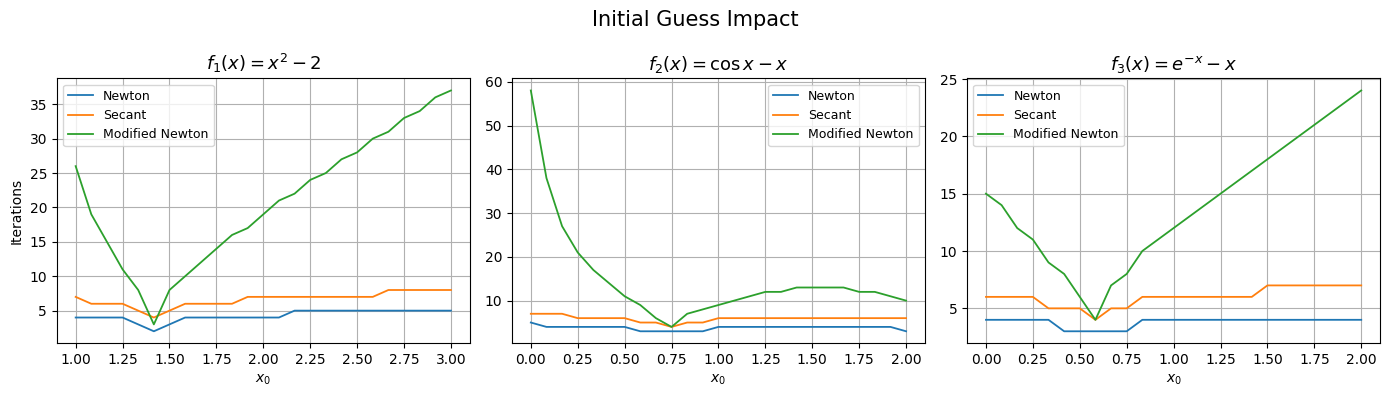

In [ ]:
method_map = {'Newton': newton, 'Secant': secant, 'Modified Newton': modified_newton}

fig, axes = plt.subplots(1, len(functions), figsize=(14, 4))

for i, (f, df, name_f) in enumerate(functions):
    ax = axes[i]
    x_0_values = np.linspace(1, 3, 25) if i == 0 else np.linspace(0, 2, 25)

    for mdef in methods:
        name, m = mdef, method_map[mdef]

        n_iters = []
        for x0 in x_0_values:
            xs = m(f, x0, x0 + 0.01, 1e-10) if name == 'Secant' else m(f, df, x0, 1e-10)
            n_iters.append(len(xs) - 1)

        ax.plot(x_0_values, n_iters, '-', lw=1.3, label=name)

    ax.set_title(name_f, fontsize=13)
    ax.set_xlabel(r'$x_0$')
    if i == 0:
        ax.set_ylabel('Iterations')
    ax.grid(True)
    ax.legend(fontsize=9)

fig.suptitle(r'Initial Guess Impact', fontsize=15) #влияние начального прибл
plt.tight_layout()
plt.show()


Метод Ньютона наиболее устойчив к начальному приближению, метод одной касательной эффективен при близком к $x^*$ начальному приближению. Видно, что в окресности корня требуется меньше итераций.

## Многомерный метод Ньютона

### Реализация многомерного метода Ньютона

Функция ``multivariate_newton(F, J, x_0, epsilon=1e-10, max_iter=4000)`` реализует многомерный метод Ньютона для нахождения корней функции $F: \mathbb{R}^n ⟶ \mathbb{R}^n, F \in C^1(\textrm{U}_\delta(x^*))$ с обратимой матрицей Якоби $J$ (матрица Якоби должна быть обратима для каждого приближения).
Принимает функцию ``F``, матрица Якоби ``J``, начальное приближение ``x_0``.
Возвращает массив приближений $x_k$ (включая нулевое). Критерий остановки: $\|\Delta x_k\| < \varepsilon$.

На каждом шаге методом Гаусса находится $\Delta x_k$ как решение системы: $$J(x_k)\Delta x_k = -F(x_k).$$

Тогда следующее приближение: $$x_{k+1} = x_k + \Delta x_k.$$

In [ ]:
def multivariate_newton(F, J, x_0, epsilon=1e-10, max_iter=4000):
  x = np.array(x_0, dtype=float)
  x_values = [x.copy()]
  iter = 0

  while iter < max_iter:
    A = J(x)
    b = (-F(x)).reshape(-1, 1)
    A_gauss, b_gauss  = Gauss(A, b)
    delta_x = backward(A_gauss, b_gauss).reshape(-1)
    x += delta_x
    x_values.append(np.array(x, dtype=float))
    iter+=1
    if np.linalg.norm(delta_x) < epsilon:
      break

  return x_values

### Тепловая карта сходимости многомерного метода Ньютона

$$
\begin{cases}
F_{1,1}(x, y) = \sin x + y^2 - 1 = 0,\\[4pt]
F_{1,2}(x, y) = x^2 - \cos y = 0.
\end{cases}
\quad \Rightarrow \quad
J_1(x, y) =
\begin{pmatrix}
\cos x & 2y\\[4pt]
2x & \sin y
\end{pmatrix}.
$$

In [ ]:
F1 = lambda x: np.array([
    np.sin(x[0]) + x[1]**2 - 1,
    x[0]**2 - np.cos(x[1])
    ])

J1 = lambda x: np.array([
    [np.cos(x[0]), 2*x[1]],
    [2*x[0], np.sin(x[1])]
    ])

Для построения тепловой карты надо понимать, к какому из решений сошелся метод. Значит, надо знать решения, чтобы ранжировать резутаты работы метода (для начальных приближений из $[-2,2]^2).$

Преобразовав систему, получим
$$\begin{cases}
y = \pm \sqrt{1-\sin x},\\[4pt]
x^2 = \cos\left(\sqrt{1-\sin x}\right).
\end{cases}$$

Если решения есть, то они лежат в двумерной клетке: $I_2 = \{(x, y): x \in [-1, 1], \, y\in [-\sqrt{2}, \sqrt{2}]\} \subset [-2, 2]^2.$

Построим графики:$$ f_1(x) = x^2, \quad f_2(x) = \cos\left(\sqrt{1-\sin x}\right).$$

Имеем два пересечения. С учетом $y = \pm \sqrt{1-\sin x}$ система имеет 4 решения.

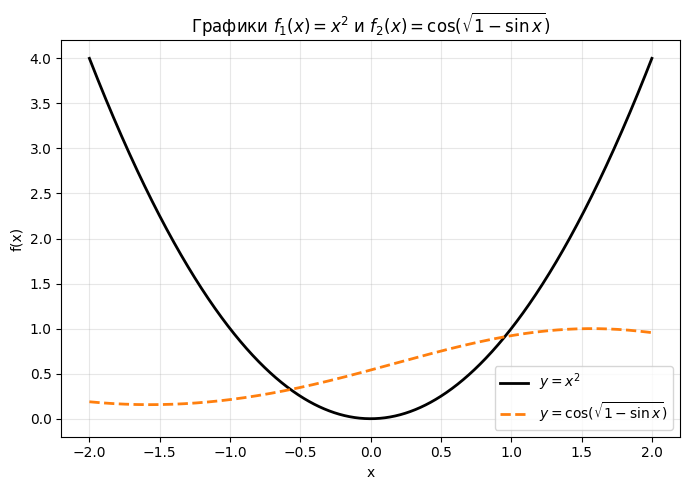

In [ ]:
x = np.linspace(-2, 2, 1000)
y1 = x**2
y2 = np.cos(np.sqrt(1 - np.sin(x)))

plt.figure(figsize=(7, 5))
plt.plot(x, y1, 'k-', lw=2, label=r'$y = x^2$')
plt.plot(x, y2, 'C1--', lw=2, label=r'$y = \cos(\sqrt{1 - \sin x})$')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'Графики $f_1(x) = x^2$ и $f_2(x) = \cos(\sqrt{1 - \sin x})$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Методом проб и ошибок подобраны 4 нулевых приближения, ведующих к решениям системы:

In [ ]:
roots = np.array([
    multivariate_newton(F1, J1, x_0=[-1.5,  1.0])[-1],
    multivariate_newton(F1, J1, x_0=[ 1.5,  1.0])[-1],
    multivariate_newton(F1, J1, x_0=[-1.5, -1.0])[-1],
    multivariate_newton(F1, J1, x_0=[ 1.5, -1.0])[-1]
])

for i, r in enumerate(roots, start=1):
    print(f"root{i} = {r}")

root1 = [-0.56939845  1.24061497]
root2 = [0.95348243 0.42960885]
root3 = [-0.56939845 -1.24061497]
root4 = [ 0.95348243 -0.42960885]


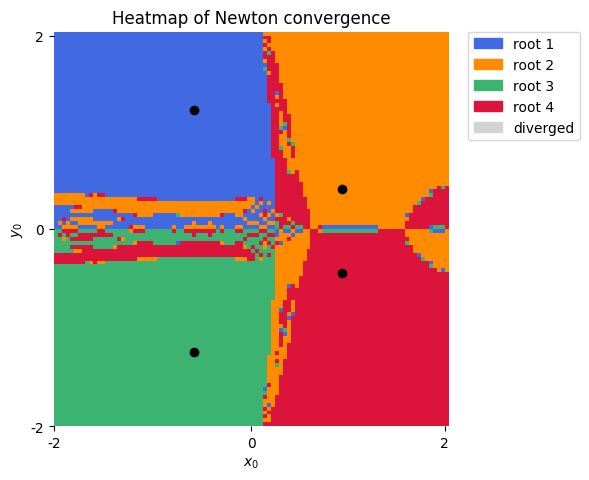

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

def identify_root(x_last, roots, tol=1e-3):
    distances = np.linalg.norm(roots - x_last, axis=1)
    min_dist = np.min(distances)
    return int(np.argmin(distances)) if min_dist < tol else -1

xs, ys = np.linspace(-2, 2, 100), np.linspace(-2, 2, 100)
points = np.empty((len(ys), len(xs)), int)

for i, y0 in enumerate(ys):
    for j, x0 in enumerate(xs):
        x_last = multivariate_newton(F1, J1, x_0=[x0, y0], epsilon=1e-8, max_iter=80)[-1]
        if np.linalg.norm(F1(x_last)) < 1e-6:
            points[i, j] = identify_root(x_last, roots)
        else:
            points[i, j] = -1

codes = np.where(points == -1, 4, points)

colors = ['royalblue', 'darkorange', 'mediumseagreen', 'crimson', 'lightgray']
labels = ['root 1', 'root 2', 'root 3', 'root 4', 'diverged']
cmap = ListedColormap(colors) #категориальная палитра
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

plt.figure(figsize=(6, 6))
sns.heatmap(codes, cmap=cmap, norm=norm, cbar=False,
            xticklabels=False, yticklabels=False, square=True)
plt.scatter(np.interp(roots[:,0], xs, np.arange(len(xs))), #interp -- подгон значений в разметку карты
    np.interp(roots[:,1], ys, np.arange(len(ys))), color = 'black') #cmap.N число цветов

plt.title("Heatmap of Newton convergence", fontsize=12)
plt.xlabel("$x_0$")
plt.ylabel("$y_0$")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)] #искуственная легенда. mpatches про прямоугольники
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) #передать список / сдвинуть правее / выровнять по левому углу / убрать отступы

plt.xlim(0, len(xs))
plt.ylim(0, len(ys))
plt.xticks([0, len(xs)//2, len(xs)-1], [-2, 0, 2])
plt.yticks([0, len(ys)//2, len(ys)-1], [-2, 0, 2])

plt.tight_layout()
plt.show()

Выбор начального приближения определяет, к какому из решений сойдется метод.

### Траектории итераций при разных начальных приближениях

$$\begin{cases}
F_{2,1}(x, y) = x^2 + y^2 - 4 = 0,\\[4pt]
F_{2,2}(x, y) = e^x + y - 1 = 0.
\end{cases}
\quad \Rightarrow \quad
J_2(x, y) =
\begin{pmatrix}
2x & 2y\\[4pt]
e^x & 1
\end{pmatrix}.$$

In [ ]:
F2 = lambda x: np.array([
    x[0]**2 + x[1]**2 - 4,
    np.exp(x[0]) + x[1] - 1
    ])

J2 = lambda x: np.array([
    [2*x[0], 2*x[1]],
    [np.exp(x[0]), 1]
    ])

Требуется построить траектории $x_k$ при разных начальных приближениях:
$$(x_0, y_0) = (-1, -1), (0, 0), (1, 1).$$

При $(x_0, y_0) = (0, 0)$ матрица Якоби $J_2(0, 0)$ вырождена. Этот случай рассматриваться не будет. Возьмем $(0, -0.5).$

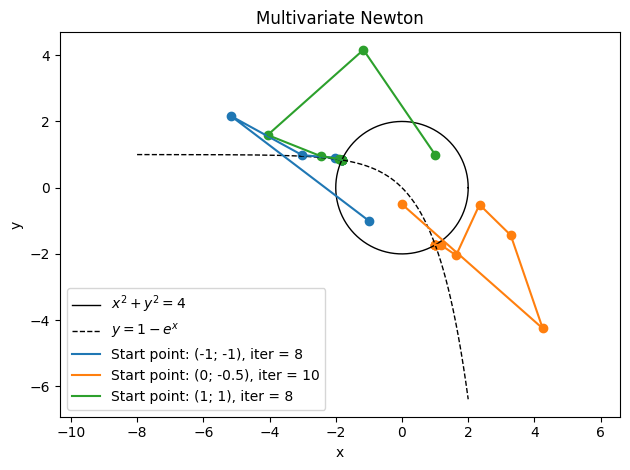

In [ ]:
t = np.linspace(0, 2*np.pi, 400)
plt.plot(2*np.cos(t), 2*np.sin(t), 'k-', lw=1, label=r'$x^2+y^2=4$') #параметрический перепляс
xs = np.linspace(-8, 2, 400)
plt.plot(xs, 1 - np.exp(xs), 'k--', lw=1, label=r'$y=1-e^x$')

x1 = np.array(multivariate_newton(F2, J2, [-1,-1]))
x2 = np.array(multivariate_newton(F2, J2, [0, -0.5]))
x3 = np.array(multivariate_newton(F2, J2, [1, 1]))

plt.scatter(x1[:,0], x1[:,1])
plt.plot(x1[:,0], x1[:,1], '-', label = f"Start point: (-1; -1), iter = {len(x1)-1}")

plt.scatter(x2[:,0], x2[:,1])
plt.plot(x2[:,0], x2[:,1], '-', label = f"Start point: (0; -0.5), iter = {len(x2)-1}")

plt.scatter(x3[:,0], x3[:,1])
plt.plot(x3[:,0], x3[:,1], '-', label = f"Start point: (1; 1), iter = {len(x3)-1}")

plt.axis('equal'); #один масштаб по осям
plt.xlabel('x'); plt.ylabel('y'); plt.title('Multivariate Newton')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
print(x1[-1], x2[-1])

[-1.81626407  0.8373678 ] [ 1.00416874 -1.72963729]


Из графика: система имеет два решения. Решения системы: $$x_1^* \approx (-1.82, 0.84), \quad x_2^* \approx (1.00, -1.73).$$

При $(x_0, y_0) = (1, 1)$ или $(-1, -1)$ метод сходится к $x_1^*$, при $(0, -0.5) \,- \,x_2^*.$ Выбор начального приближения (корректного) влияет на результат метода.